# GHG Emission Note: Calculate Total CO₂e

This notebook calculates total greenhouse gas (GHG) emissions in CO₂ equivalent (CO₂e) from emission factors (EFs) of three major gases:

- **CO₂ (Carbon dioxide)**
- **CH₄ (Methane)**
- **N₂O (Nitrous oxide)**

Only these three are considered **direct greenhouse gases** in standard GHG inventories.

# Steps:
1. Input emission factors (EF) in grams per unit of fuel or activity.
2. Use IPCC AR6 100-year Global Warming Potentials (GWP):
   - CH₄ → 29.8
   - N₂O → 273
   - CO₂ → 1 (baseline)

3. Apply the formula
  Total CO₂e = CO₂ + (CH₄ × GWP_CH₄) + (N₂O × GWP_N₂O)


# DATA:
  From GREET 2024 per mmbtu diesel fuel for framing tractor:
  EF_CH4=0.630
  EF_N2O=0.920
  EF_CO2=77,754

  Diesel for non-road engines heating value:
  128,450 BTU/gal
  3.78541 liters in a gallon
  128,450 BTU/gallon = 33,933 BTU/liter

  1000000btu/ (33933btu/liter)=29.47 liter

  per liter diesel fuel for framing tractor:
  EF_CH4=0.630/29.47
  EF_N2O=0.920/29.47
  EF_CO2=77,754/29.47

  total CO₂e for per liter of diesel fuel:
  Total CO₂e = 77,754/29.47 + (0.630/29.47 × 29.8) + (0.920/29.47 × 273) = 2647g
  =2.647kg/liter

  GHG-100 FOR conventional diesel from crude oil for us refineries
  = 0.55kg/liter

  2.647+0.55 = 3.197kg/liter

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
font_dirs = ["/content/drive/MyDrive/NU work/Font"]  # The path to the custom font file./content/Arial.ttf
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

print(font_files)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
font_manager.get_font_names()


plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['hatch.linewidth'] = 0.5

['/content/drive/MyDrive/NU work/Font/Arial Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold Italic.ttf', '/content/drive/MyDrive/NU work/Font/Arial Bold.ttf']


   State  Diesel (L/1000kg)  Electricity (kWh/1000kg)  Current Rate  \
0     AL               33.7                     414.1          -7.8   
1     AZ               95.6                    1101.1         -11.3   
2     AR               71.0                     490.4         -12.6   
3     CA               94.9                     574.3          -4.6   
4     FL              110.2                     463.1          -5.7   
5     GA               56.4                     741.2          -9.1   
6     KS              101.3                    1172.8          -7.3   
7     LA               82.4                     523.5         -12.6   
8     MS               77.5                     465.7         -12.5   
9     MO               93.8                     746.2          -8.3   
10    NC               75.5                     994.9         -10.0   
11    NM              199.9                    2082.1          -7.4   
12    OK              114.3                    1214.6          -5.0   
13    

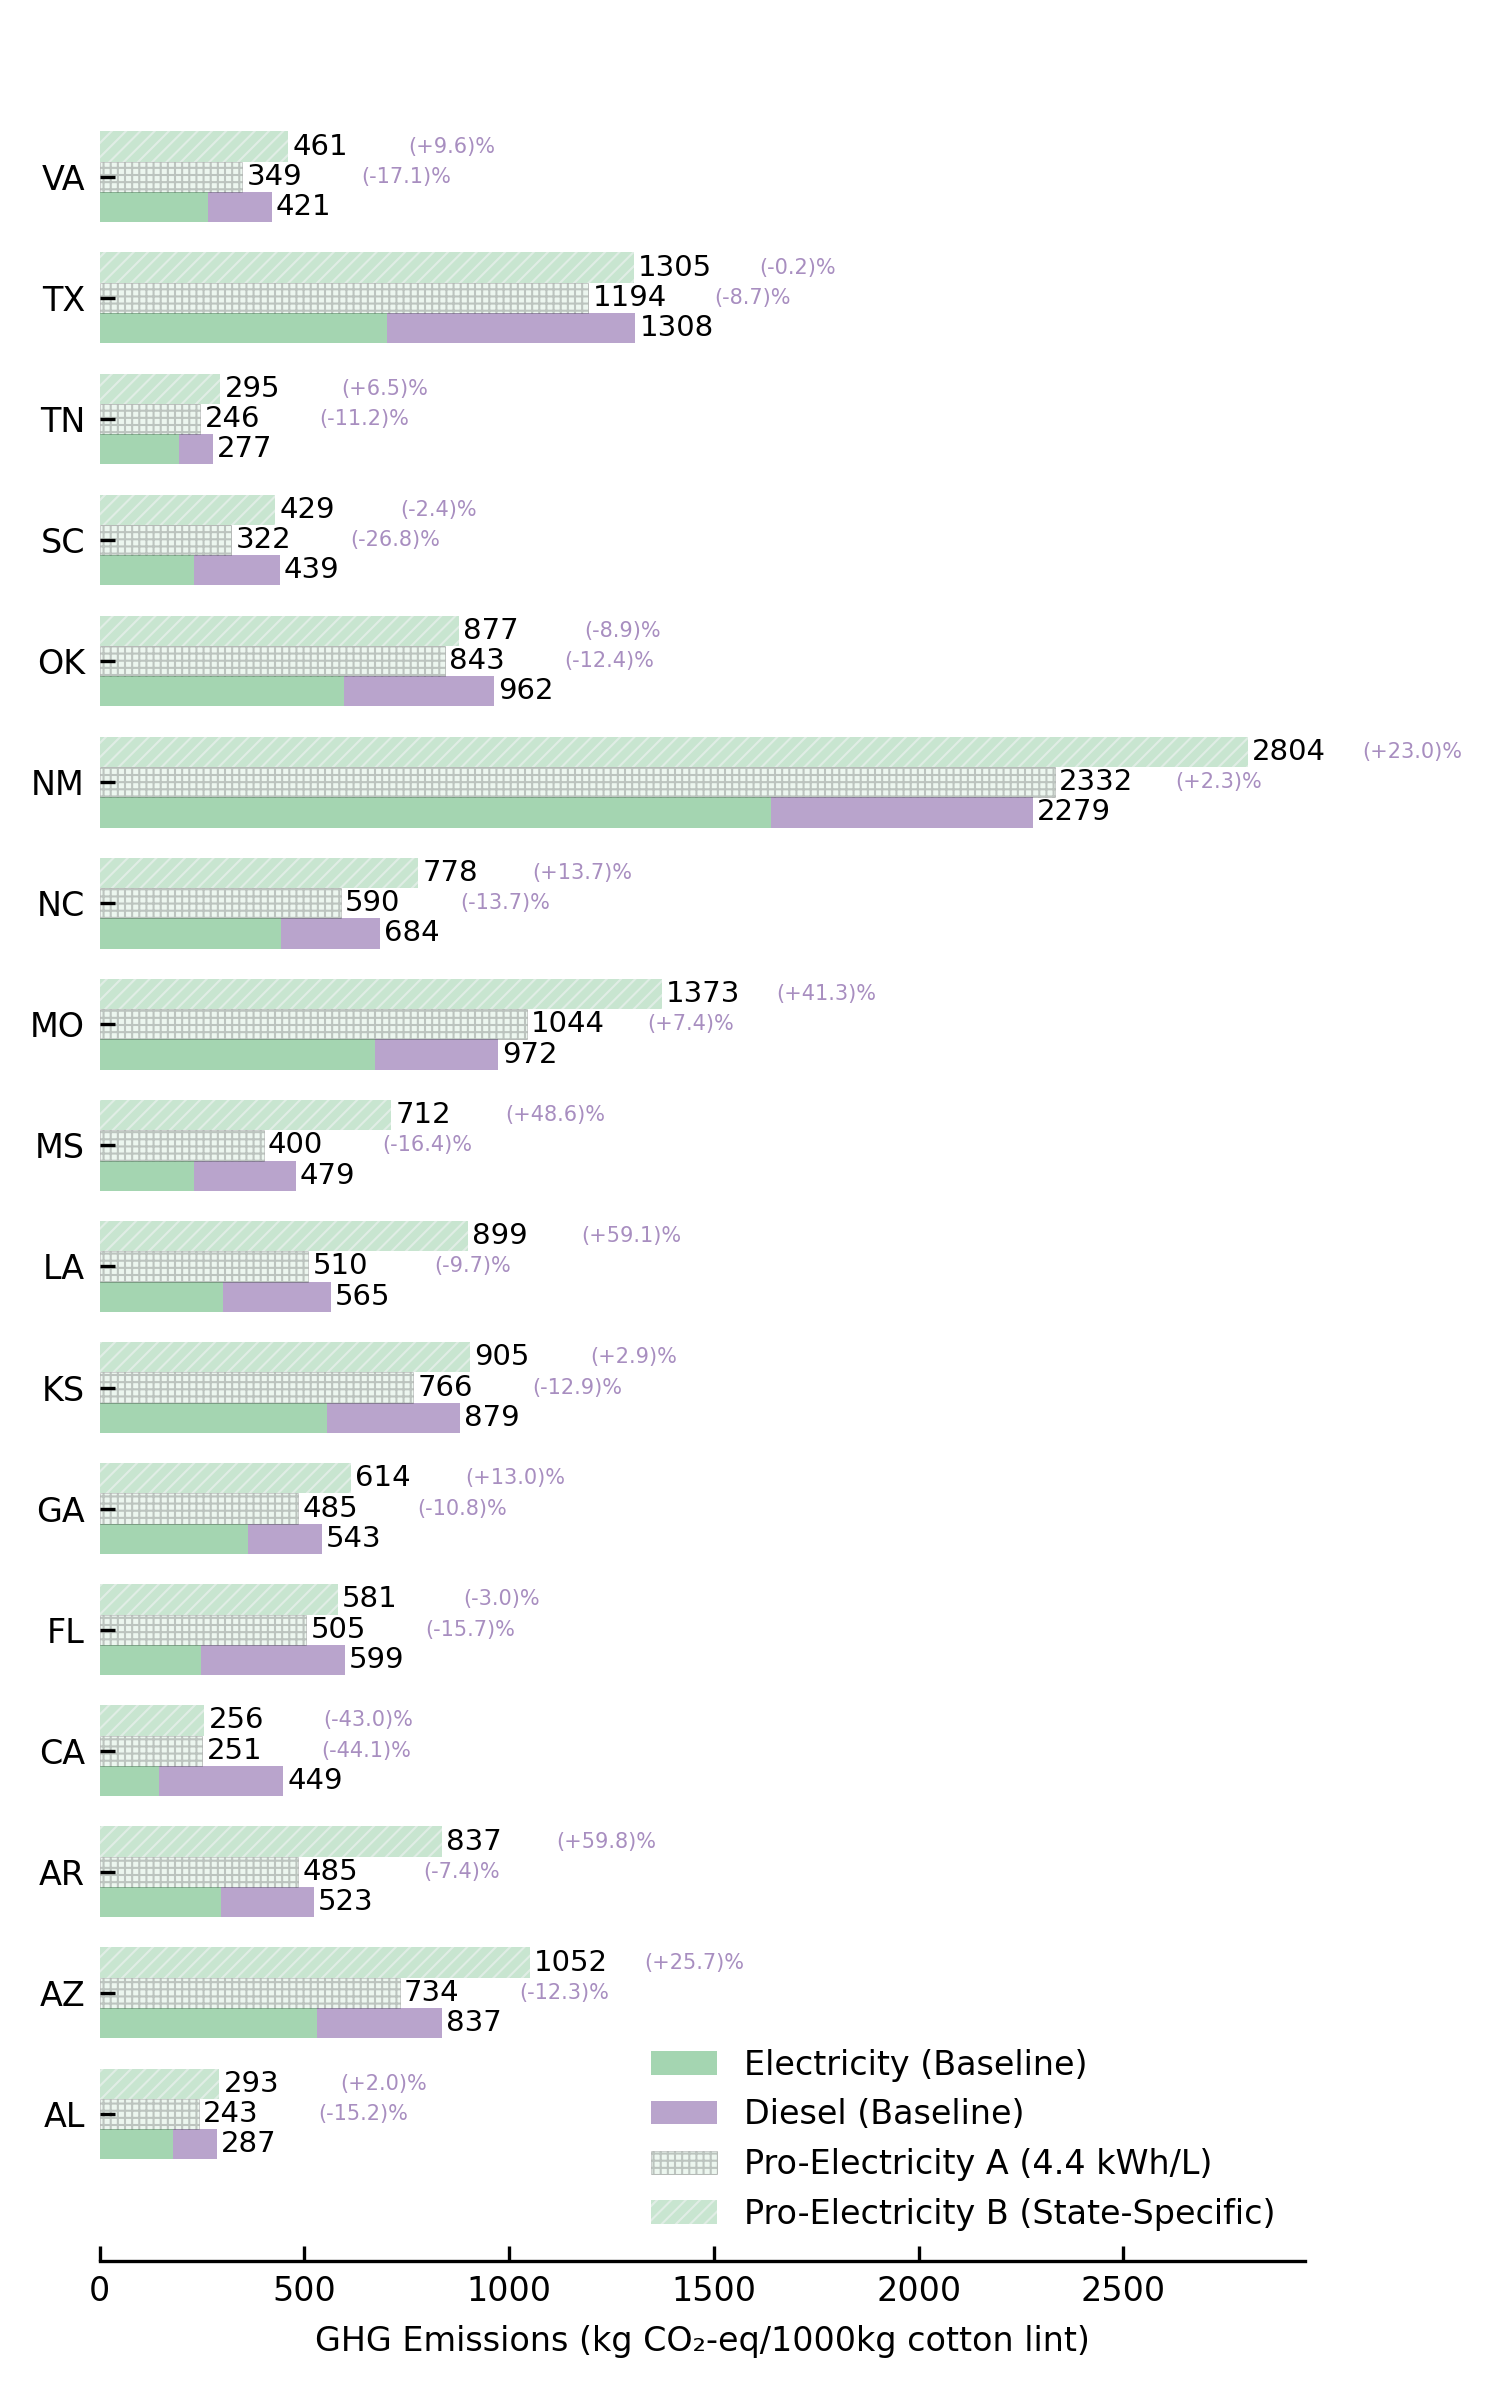

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data
data = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/processed_data and results/Energy_Analysis_Summary.xlsx')
print(data)

df=data
# Constant diesel EF
EF_diesel = 3.2  # kg CO2-eq/L  data for year 2025 from GREET model

# Baseline
df['GHG_Electricity'] = df['Electricity (kWh/1000kg)'] * df['State-specific EF (kg CO2-eq/kWh)']
df['GHG_Diesel'] = df['Diesel (L/1000kg)'] * EF_diesel
df['GHG_Baseline'] = df['GHG_Electricity'] + df['GHG_Diesel']

# Pro-Electricity A: Uniform conversion, state-specific EF
conversion_A = 4.4
df['Electricity_A'] = df['Electricity (kWh/1000kg)'] + df['Diesel (L/1000kg)'] * conversion_A
df['GHG_A'] = df['Electricity_A'] * df['State-specific EF (kg CO2-eq/kWh)']

# Pro-Electricity B: State-specific conversion + EF
df['Electricity_B'] = df['Electricity (kWh/1000kg)'] - df['Diesel (L/1000kg)'] * df['Current Rate']
df['GHG_B'] = df['Electricity_B'] * df['State-specific EF (kg CO2-eq/kWh)']

# Plotting - HORIZONTAL VERSION
y = np.arange(len(df))
height = 0.25

fig, ax = plt.subplots(figsize=(5, 8))  # Adjusted figure size for horizontal plot

# Baseline (stacked) - using barh for horizontal bars
ax.barh(y - height, df['GHG_Electricity'], height, label='Electricity (Baseline)', color='#A4D5B1')
ax.barh(y - height, df['GHG_Diesel'], height, left=df['GHG_Electricity'], label='Diesel (Baseline)', color='#A88EC0', alpha=0.8)

# Scenario A
ax.barh(y, df['GHG_A'], height, label='Pro-Electricity A (4.4 kWh/L)',alpha=0.2, color='#A4D5B1', hatch='+++++++', edgecolor='k',linewidth=0.2)

# Scenario B
ax.barh(y + height, df['GHG_B'], height, label='Pro-Electricity B (State-Specific)',alpha=0.6, color='#A4D5B1', hatch='///////', edgecolor='#F1F3F4',linewidth=0)

# Labels
ax.set_xlabel('GHG Emissions (kg CO₂-eq/1000kg cotton lint)')
# ax.set_title('GHG Emissions per 1000 kg Cotton Lint: Baseline vs Electrification Scenarios')
ax.set_yticks(y)
ax.set_yticklabels(df['State'])
ax.legend(frameon=False)

# Annotate values
for i in y:
    # Baseline total
    ax.text(df['GHG_Baseline'][i] + 10, i - height, f"{df['GHG_Baseline'][i]:.0f}", va='center', fontsize=7)
    # Scenario A
    ax.text(df['GHG_A'][i] + 10, i, f"{df['GHG_A'][i]:.0f}", va='center', fontsize=7)
    # Scenario B
    ax.text(df['GHG_B'][i] + 10, i + height, f"{df['GHG_B'][i]:.0f}", va='center', fontsize=7)

# Annotate percentage change for Scenario A and B
for i in y:
    ghg_base = df['GHG_Baseline'][i]

    # Scenario A
    ghg_a = df['GHG_A'][i]
    change_a = 100 * (ghg_a - ghg_base) / ghg_base
    ax.text(ghg_a + 400, i, f"({change_a:+.1f})%", va='center', ha='center',color='#A88EC0', fontsize=5)

    # Scenario B
    ghg_b = df['GHG_B'][i]
    change_b = 100 * (ghg_b - ghg_base) / ghg_base
    ax.text(ghg_b + 400, i + height, f"({change_b:+.1f})%", va='center', ha='center', color='#A88EC0', fontsize=5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/state_level_energy.tiff',dpi=300, bbox_inches='tight')
plt.show()

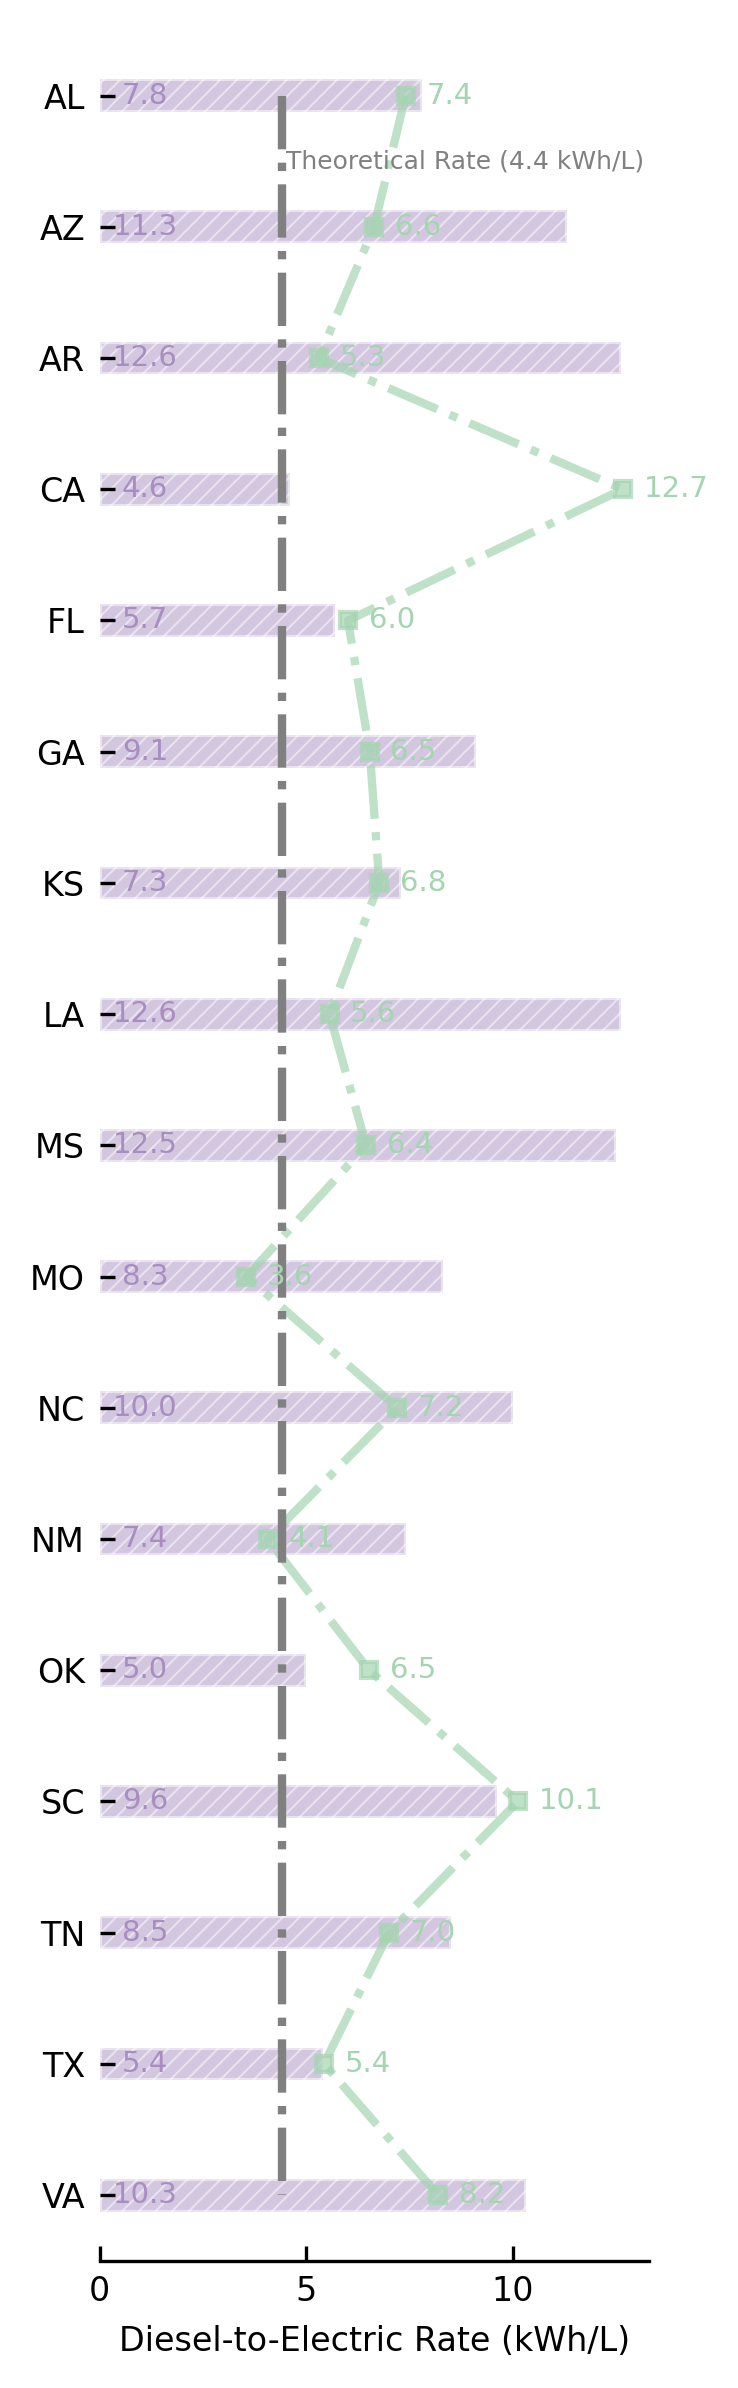

In [ ]:
# Separate line plot for fuel usage data with annotations
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming you have the same df from your main plot
y = np.arange(len(df))

# Create separate figure for fuel usage lines - MATCHING HEIGHT AND Y-AXIS
height = 0.25  # Same height variable as main plot
fig, ax = plt.subplots(figsize=(2.5, 8))  # Same figure height as main plot

# Define colors to match your theme
line_colors = ['#A88EC0', '#A4D5B1', 'grey']
line_styles = ['--', '-.', '-.']  # Different line styles for distinction

# Plot three line series
# Line 1: Current Rate (Bar plot) - using same height as main plot
if 'Current Rate' in df.columns:
    bars = ax.barh(y, abs(df['Current Rate']), height,
                   color=line_colors[0], hatch='//////',edgecolor='white', alpha=0.5, label='Current Rate')

    # Annotate bars
    for i in y:
        value = abs(df['Current Rate'].iloc[i])
        ax.text(1.1, i, f'{value:.1f}',
                va='center', ha='center', fontsize=7, color='#A88EC0')

# Line 2: GHG Reduction Rate (Line plot)
if 'State-specific EF (kg CO2-eq/kWh)' in df.columns:
    ghg_reduction_rate = 3.2/df['State-specific EF (kg CO2-eq/kWh)']
    line1 = ax.plot(ghg_reduction_rate, y,
                    color=line_colors[1], linewidth=2, alpha=0.7, linestyle=line_styles[1],
                    label='Ideal Rate', marker='s', markersize=4)

    # Annotate line dots
    for i in y:
        value = ghg_reduction_rate.iloc[i]
        ax.text(value + 0.5, i, f'{value:.1f}',
                va='center', ha='left', fontsize=7, color='#A4D5B1')

# Line 3: Theoretical Rate (Constant line)
total_energy = df['Electricity (kWh/1000kg)']*0.0 + (4.4)
line2 = ax.plot(total_energy, y,
                color=line_colors[2], linewidth=2, linestyle=line_styles[2],
                markersize=4)

# Annotate the constant theoretical rate (only once to avoid clutter)
ax.text(4.4 + 0.1, 0.5, 'Theoretical Rate (4.4 kWh/L)',
        va='center', ha='left', fontsize=6, color='grey')

# Format the plot to match your main plot style
ax.set_ylim(-0.5, len(df) - 0.5)
ax.set_yticks(y)
ax.set_yticklabels(df['State'])
ax.set_xlabel('Diesel-to-Electric Rate (kWh/L)', fontsize=8)

# Invert y-axis to match your main plot (if states are in same order)
ax.invert_yaxis()

# Add legend
# ax.legend(frameon=False, fontsize=8)
# Top of plot
# ax.legend(frameon=False, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=2, fontsize=8)
# Remove spines to match your main plot style EXACTLY
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)  # Match main plot by removing left spine too

# Add grid for better readability
# ax.grid(True, axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/state_level_convertion_rate.tiff',dpi=300, bbox_inches='tight')
plt.show()

   State  Diesel (L/1000kg)  Electricity (kWh/1000kg)  Current Rate  \
0     AL               33.7                     414.1          -7.8   
1     AZ               95.6                    1101.1         -11.3   
2     AR               71.0                     490.4         -12.6   
3     CA               94.9                     574.3          -4.6   
4     FL              110.2                     463.1          -5.7   
5     GA               56.4                     741.2          -9.1   
6     KS              101.3                    1172.8          -7.3   
7     LA               82.4                     523.5         -12.6   
8     MS               77.5                     465.7         -12.5   
9     MO               93.8                     746.2          -8.3   
10    NC               75.5                     994.9         -10.0   
11    NM              199.9                    2082.1          -7.4   
12    OK              114.3                    1214.6          -5.0   
13    

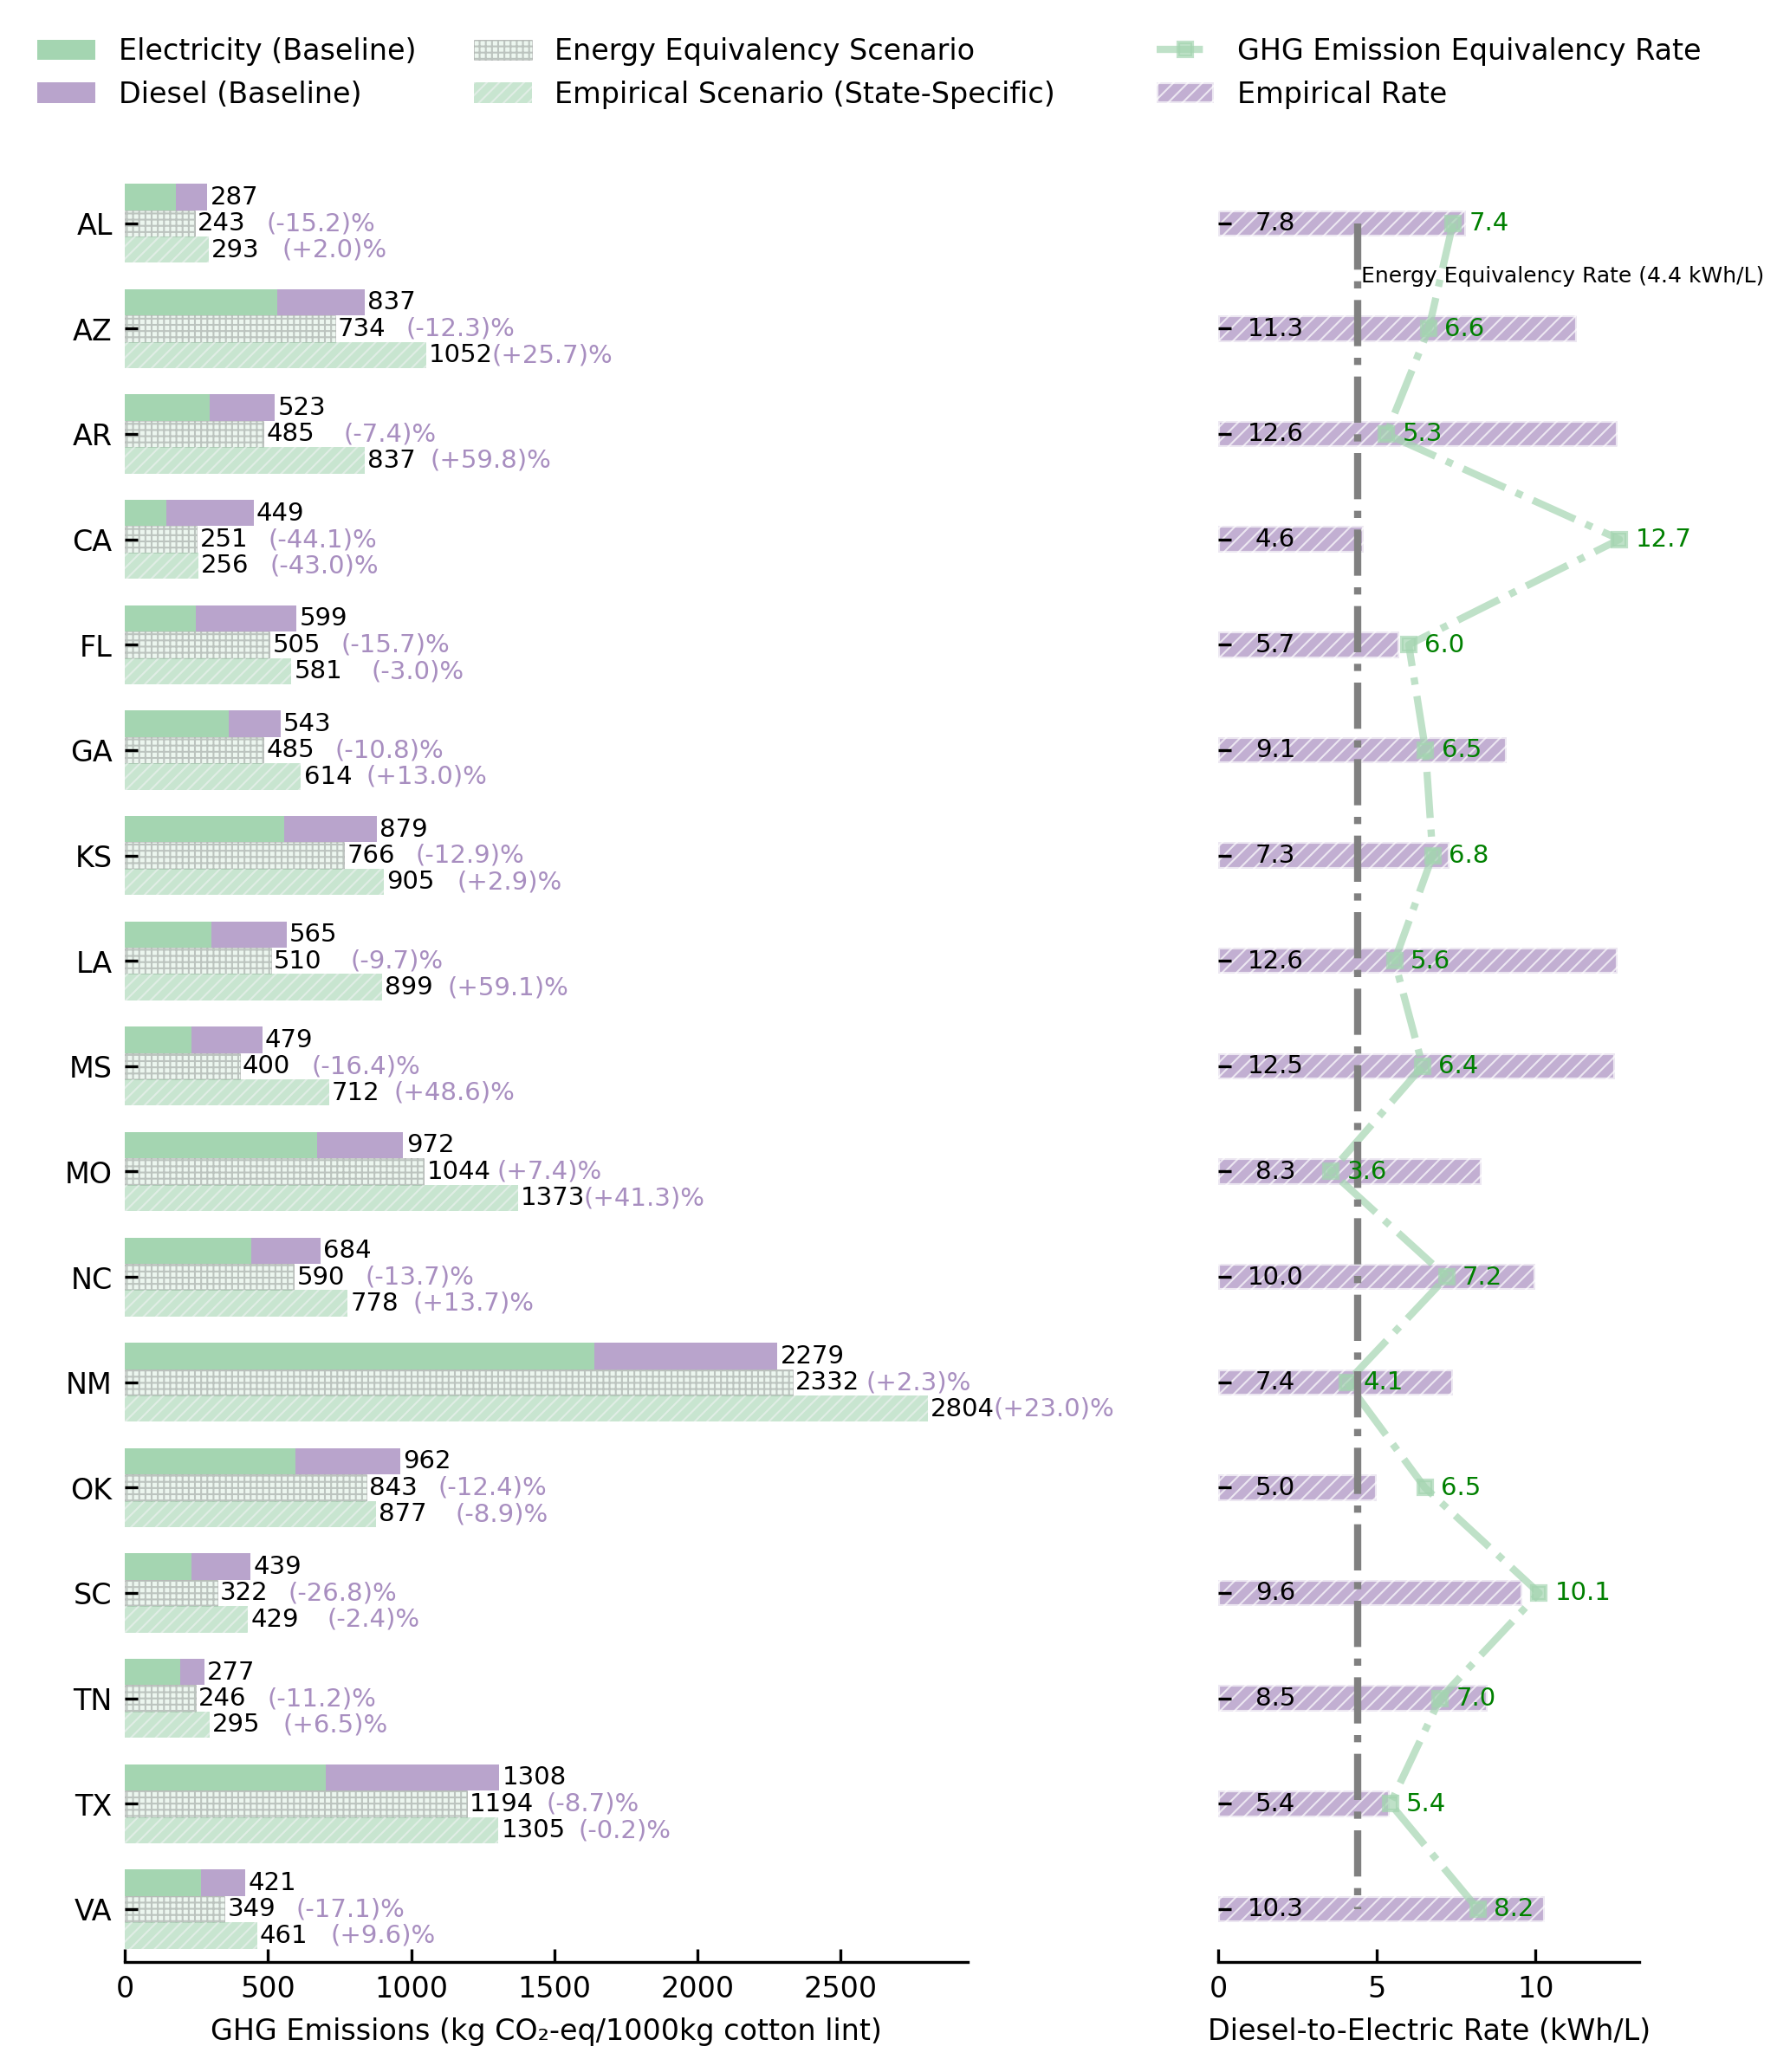

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data
data = pd.read_excel('/content/drive/MyDrive/NU work/Cotton/cotton_github/results/processed_data and results/Energy_Analysis_Summary.xlsx')
print(data)

df = data
# Constant diesel EF
EF_diesel = 3.2  # kg CO2-eq/L  data for year 2025 from GREET model

# Baseline
df['GHG_Electricity'] = df['Electricity (kWh/1000kg)'] * df['State-specific EF (kg CO2-eq/kWh)']
df['GHG_Diesel'] = df['Diesel (L/1000kg)'] * EF_diesel
df['GHG_Baseline'] = df['GHG_Electricity'] + df['GHG_Diesel']

# Pro-Electricity A: Uniform conversion, state-specific EF
conversion_A = 4.4
df['Electricity_A'] = df['Electricity (kWh/1000kg)'] + df['Diesel (L/1000kg)'] * conversion_A
df['GHG_A'] = df['Electricity_A'] * df['State-specific EF (kg CO2-eq/kWh)']

# Pro-Electricity B: State-specific conversion + EF
df['Electricity_B'] = df['Electricity (kWh/1000kg)'] - df['Diesel (L/1000kg)'] * df['Current Rate']
df['GHG_B'] = df['Electricity_B'] * df['State-specific EF (kg CO2-eq/kWh)']

# COMBINED PLOTTING - Two subplots sharing y-axis
y = np.arange(len(df))
height = 0.25

# Create figure with two subplots sharing y-axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.92, 8), sharey=True, gridspec_kw={'width_ratios': [2, 1]})

# LEFT PLOT: GHG Emissions
# Baseline (stacked) - using barh for horizontal bars
ax1.barh(y - height, df['GHG_Electricity'], height, label='Electricity (Baseline)', color='#A4D5B1')
ax1.barh(y - height, df['GHG_Diesel'], height, left=df['GHG_Electricity'], label='Diesel (Baseline)', color='#A88EC0', alpha=0.8)

# Scenario A
ax1.barh(y, df['GHG_A'], height, label='Energy Equivalency Scenario', alpha=0.2, color='#A4D5B1', hatch='+++++++', edgecolor='k', linewidth=0.2)

# Scenario B
ax1.barh(y + height, df['GHG_B'], height, label='Empirical Scenario (State-Specific)', alpha=0.6, color='#A4D5B1', hatch='///////', edgecolor='#F1F3F4', linewidth=0)

# Labels for left plot
ax1.set_xlabel('GHG Emissions (kg CO₂-eq/1000kg cotton lint)')
ax1.set_yticks(y)
ax1.set_yticklabels(df['State'])
# ax1.legend(frameon=False, loc='upper right')
ax1.legend(frameon=False, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=2)

# Annotate values for left plot
for i in y:
    # Baseline total
    ax1.text(df['GHG_Baseline'][i] + 10, i - height, f"{df['GHG_Baseline'][i]:.0f}", va='center', fontsize=7)
    # Scenario A
    ax1.text(df['GHG_A'][i] + 10, i, f"{df['GHG_A'][i]:.0f}", va='center', fontsize=7)
    # Scenario B
    ax1.text(df['GHG_B'][i] + 10, i + height, f"{df['GHG_B'][i]:.0f}", va='center', fontsize=7)

# Annotate percentage change for Scenario A and B
for i in y:
    ghg_base = df['GHG_Baseline'][i]

    # Scenario A
    ghg_a = df['GHG_A'][i]
    change_a = 100 * (ghg_a - ghg_base) / ghg_base
    ax1.text(ghg_a + 440, i, f"({change_a:+.1f})%", va='center', ha='center', color='#A88EC0', fontsize=7)

    # Scenario B
    ghg_b = df['GHG_B'][i]
    change_b = 100 * (ghg_b - ghg_base) / ghg_base
    ax1.text(ghg_b + 440, i + height, f"({change_b:+.1f})%", va='center', ha='center', color='#A88EC0', fontsize=7)

# Remove spines for left plot
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

# RIGHT PLOT: Conversion Rates
# Define colors to match your theme
line_colors = ['#A88EC0', '#A4D5B1', 'grey']
line_styles = ['--', '-.', '-.']

# Current Rate (Bar plot)
if 'Current Rate' in df.columns:
    bars = ax2.barh(y, abs(df['Current Rate']), height,
                   color=line_colors[0], hatch='//////', edgecolor='white', alpha=0.7, label='Empirical Rate')

    # Annotate bars
    for i in y:
        value = abs(df['Current Rate'].iloc[i])
        ax2.text(1.8, i, f'{value:.1f}',
                va='center', ha='center', fontsize=7, color='k')

# GHG Reduction Rate (Line plot)
if 'State-specific EF (kg CO2-eq/kWh)' in df.columns:
    ghg_reduction_rate = 3.2/df['State-specific EF (kg CO2-eq/kWh)']
    line1 = ax2.plot(ghg_reduction_rate, y,
                    color=line_colors[1], linewidth=2, alpha=0.7, linestyle=line_styles[1],
                    label='GHG Emission Equivalency Rate', marker='s', markersize=4)

    # Annotate line dots
    for i in y:
        value = ghg_reduction_rate.iloc[i]
        ax2.text(value + 0.5, i, f'{value:.1f}',
                va='center', ha='left', fontsize=7, color='green')

# Theoretical Rate (Constant line)
total_energy = df['Electricity (kWh/1000kg)']*0.0 + (4.4)
line2 = ax2.plot(total_energy, y,
                color=line_colors[2], linewidth=2, linestyle=line_styles[2], markersize=4)

# Annotate the constant theoretical rate
ax2.text(4.4 + 0.1, 0.5, 'Energy Equivalency Rate (4.4 kWh/L)',
        va='center', ha='left', fontsize=6, color='k')

# Labels for right plot
ax2.set_xlabel('Diesel-to-Electric Rate (kWh/L)', fontsize=8)

# Remove y-axis labels for right plot since it shares with left
ax1.set_yticklabels(df['State'])

# Remove spines for right plot
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

ax2.legend(frameon=False, bbox_to_anchor=(0.5, 1.02), loc='lower center', ncol=1)
# Set same y limits and invert for both plots
ax1.set_ylim(-0.5, len(df) - 0.5)
ax2.set_ylim(-0.5, len(df) - 0.5)
ax1.invert_yaxis()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/NU work/Cotton/Figures/combined_state_level_analysis.tiff', dpi=300, bbox_inches='tight')
plt.show()